In [28]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix,roc_curve

In [3]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_ab8f16dea2910e6ee9c3aea2626de363'

path = kagglehub.competition_download('santander-customer-transaction-prediction')
path

100%|██████████| 250M/250M [00:02<00:00, 91.5MB/s]

Extracting files...


'/root/.cache/kagglehub/competitions/santander-customer-transaction-prediction'

In [4]:
df = pd.read_csv('/root/.cache/kagglehub/competitions/santander-customer-transaction-prediction/train.csv')
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [6]:
df.isnull().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,0
var_196,0
var_197,0
var_198,0


In [7]:
X = df.drop(columns=['ID_code', 'target'])
y = df['target']

In [8]:
df['target'].value_counts()


,count
target,
0,179902
1,20098


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [10]:
#Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
logistic_reg = LogisticRegression(solver = 'saga' , class_weight = 'balanced')

In [35]:
C_values = [0.001, 0.01, 0.1, 0.5, 1, 10, 100]
results = []

for C in C_values:
    logistic_reg = LogisticRegression(C=C, class_weight='balanced', max_iter=1000, random_state= 30)
    logistic_reg.fit(X_train, y_train)

    y_pred = logistic_reg.predict(X_test)


    results.append({
        'C': C,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred), })

results_df = pd.DataFrame(results)
print(results_df)

         C  Accuracy  Precision    Recall        F1
0    0.001  0.781650   0.292324  0.784936  0.425999
1    0.010  0.781225   0.291839  0.784694  0.425448
2    0.100  0.781275   0.291929  0.784936  0.425579
3    0.500  0.781225   0.291839  0.784694  0.425448
4    1.000  0.781225   0.291839  0.784694  0.425448
5   10.000  0.781225   0.291839  0.784694  0.425448
6  100.000  0.781225   0.291839  0.784694  0.425448


In [13]:
from sklearn.model_selection import GridSearchCV
parameter = {'C': [0.001,0.01,0.1,0.5,1,10,50,100] , 'penalty':['l1','l2','elasticnet'] , 'max_iter':[100,200,500,1000,]}

In [14]:
classifier_reg = GridSearchCV( logistic_reg, param_grid =  parameter, scoring = 'precision', cv=5)

In [15]:
classifier_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
320 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_sol

GridSearchCV(cv=5,
             estimator=LogisticRegression(C=100, class_weight='balanced',
                                          max_iter=1000, random_state=30),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1, 10, 50, 100],
                         'max_iter': [100, 200, 500, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='precision')

In [19]:
classifier_reg.best_params_

{'C': 0.001, 'max_iter': 100, 'penalty': 'l2'}

In [20]:
classifier_reg.best_score_

np.float64(0.28270173827580225)

In [21]:
y_pred =classifier_reg.predict(X_test)

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35871
           1       0.29      0.78      0.43      4129

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.65     40000
weighted avg       0.90      0.78      0.82     40000



In [23]:
confusion_matrix(y_test ,y_pred)

array([[28025,  7846],
       [  888,  3241]])

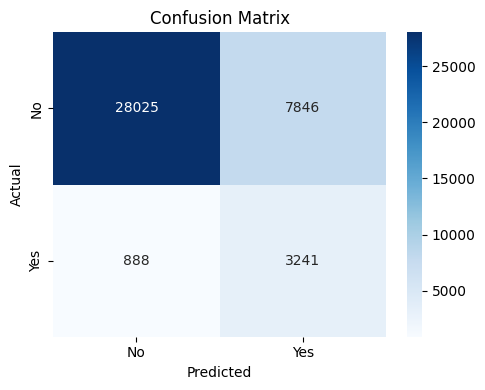

In [27]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

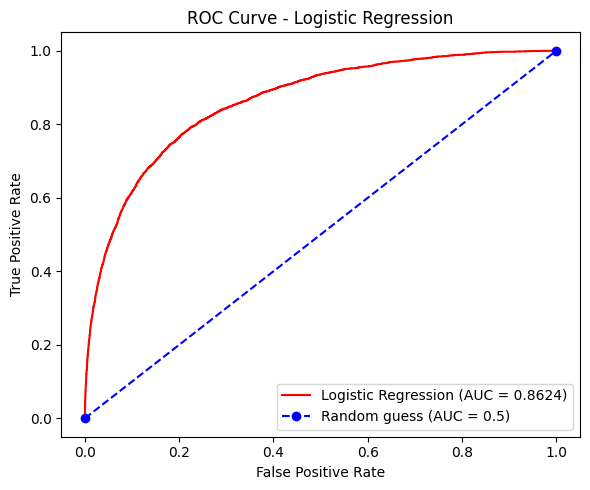

ROC-AUC Score: 0.8624


In [40]:
y_proba = classifier_reg.predict_proba(X_test)[:, 1]

# Computing ROC curve points and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='red', label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'bo--', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc:.4f}")